In [7]:
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import scipy.sparse as sp
import scvi
import cellxgene_census  # pip install cellxgene-census

# 1. Load In-House Data

In [8]:
adata_fus = sc.read_10x_mtx('../fused/', var_names='gene_symbols', cache=True)
adata_fus.obs['sample'] = 'fused'
adata_fus.obs.index = [f'F_{bc}' for bc in adata_fus.obs.index]

adata_par = sc.read_10x_mtx('../parental/', var_names='gene_symbols', cache=True)
adata_par.obs['sample'] = 'parental'
adata_par.obs.index = [f'P_{bc}' for bc in adata_par.obs.index]

adata_res = sc.read_10x_mtx('../resistant/', var_names='gene_symbols', cache=True)
adata_res.obs['sample'] = 'resistant'
adata_res.obs.index = [f'R_{bc}' for bc in adata_res.obs.index]

for adata in [adata_fus, adata_par, adata_res]:
    adata.var_names_make_unique()
    adata.obs['source'] = 'in_house'

print(adata_fus)
print(adata_par)
print(adata_res)

adata_inhouse = ad.concat([adata_fus, adata_par, adata_res], join='outer')

AnnData object with n_obs × n_vars = 6044 × 36601
    obs: 'sample', 'source'
    var: 'gene_ids', 'feature_types'
AnnData object with n_obs × n_vars = 10353 × 36601
    obs: 'sample', 'source'
    var: 'gene_ids', 'feature_types'
AnnData object with n_obs × n_vars = 8513 × 36601
    obs: 'sample', 'source'
    var: 'gene_ids', 'feature_types'


# 2. Create the artificial batch effect

In [13]:
adata = adata_inhouse

# adata.X must be raw counts
np.random.seed(42)

# --- Split into 2 artificial batches ---
batch_labels = np.random.choice(["batch_0", "batch_1"], size=adata.n_obs, p=[0.5, 0.5])
adata.obs["artificial_batch"] = batch_labels

# --- Select genes to perturb ---
N_PERTURBED = 50        # ~1-2% of HVGs is realistic
MEAN_ADDED  = 8         # mean counts added per cell; scale to your library size
DISPERSION  = 2         # NegBin r; lower = more overdispersed (more realistic)

perturbed_genes = np.random.choice(adata.var_names, size=N_PERTURBED, replace=False)
adata.var["is_perturbed"] = adata.var_names.isin(perturbed_genes)

# --- Add NegBinomial counts to batch_1 only ---
X = adata.X.toarray() if sp.issparse(adata.X) else adata.X.copy().astype(float)

batch1_mask = (adata.obs["artificial_batch"] == "batch_1").values
gene_idx    = np.where(adata.var["is_perturbed"])[0]

p = DISPERSION / (DISPERSION + MEAN_ADDED)
added = np.random.negative_binomial(
    n=DISPERSION, p=p,
    size=(batch1_mask.sum(), N_PERTURBED)
)
X[np.ix_(batch1_mask, gene_idx)] += added
adata.X = sp.csr_matrix(X)

# Sanity check: confirm the batch effect is real
mean_b0 = np.array(adata[adata.obs.artificial_batch=="batch_0", perturbed_genes].X.mean(axis=0)).flatten()
mean_b1 = np.array(adata[adata.obs.artificial_batch=="batch_1", perturbed_genes].X.mean(axis=0)).flatten()
print(f"Mean counts in perturbed genes — batch_0: {mean_b0.mean():.2f}, batch_1: {mean_b1.mean():.2f}")
# batch_1 should be ~MEAN_ADDED higher

Mean counts in perturbed genes — batch_0: 0.50, batch_1: 8.50


# 3. Preprocess and UMAP before correction

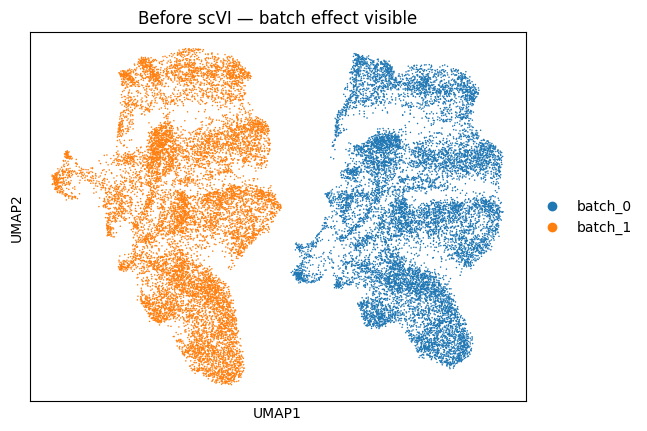

In [14]:
adata.layers["counts"] = adata.X.copy()  # scVI needs raw counts in a layer

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.raw = adata

sc.pp.highly_variable_genes(
    adata, n_top_genes=3000,
    batch_key="artificial_batch",  # use batch-aware HVG selection
    subset=True
)

sc.pp.pca(adata)
sc.pp.neighbors(adata, use_rep="X_pca")
sc.tl.umap(adata)
sc.pl.umap(adata, color=["artificial_batch"],
           title="Before scVI — batch effect visible")

# 4. Train SCVI

/home/pvs13/venvs/scvi/lib/python3.12/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[counts] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)
/home/pvs13/venvs/scvi/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/pvs13/venvs/scvi/lib/python3.12/site-packages/ ...
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/home/pvs13/venvs/scvi/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is 

Training:   0%|          | 0/400 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=400` reached.


<Axes: xlabel='epoch'>

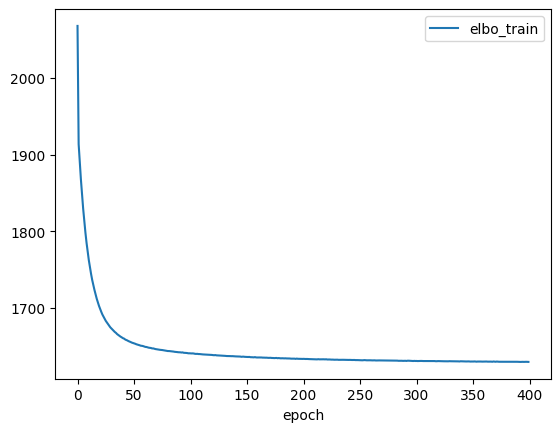

In [15]:
scvi.model.SCVI.setup_anndata(
    adata,
    layer="counts",
    batch_key="artificial_batch"
)

model = scvi.model.SCVI(
    adata,
    n_layers=2,
    n_latent=10,
    gene_likelihood="nb"
)

model.train(
    max_epochs=400,
    early_stopping=True,
    early_stopping_patience=20,
    plan_kwargs={"lr": 1e-3}
)

model.history["elbo_train"].plot()   # check convergence

# 5. Evaluate Batch mixing

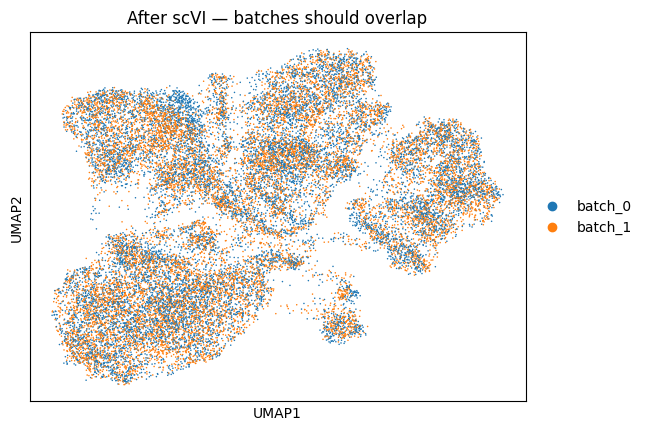

LISI (PCA, pre-correction):  1.000
LISI (scVI, post-correction): 1.793


In [16]:
adata.obsm["X_scVI"] = model.get_latent_representation()

sc.pp.neighbors(adata, use_rep="X_scVI")
sc.tl.umap(adata)
sc.pl.umap(adata, color=["artificial_batch"],
           title="After scVI — batches should overlap")

# --- LISI score: 1.0 = no mixing, 2.0 = perfect mixing for 2 batches ---
from sklearn.neighbors import NearestNeighbors

def lisi(X_emb, labels, k=30):
    nn = NearestNeighbors(n_neighbors=k).fit(X_emb)
    _, idx = nn.kneighbors(X_emb)
    scores = []
    for neighbors in idx:
        lab = labels[neighbors]
        vals, counts = np.unique(lab, return_counts=True)
        freq = counts / counts.sum()
        scores.append(1 / (freq**2).sum())
    return np.array(scores)

batch_arr = adata.obs["artificial_batch"].values
print(f"LISI (PCA, pre-correction):  {lisi(adata.obsm['X_pca'][:,:10], batch_arr).mean():.3f}")
print(f"LISI (scVI, post-correction): {lisi(adata.obsm['X_scVI'], batch_arr).mean():.3f}")

# 6. verify scvi removed batch effects

In [17]:
# Get scVI's batch-corrected expression
corrected = model.get_normalized_expression(
    adata, library_size=1e4, transform_batch="batch_0"  # project everything to batch_0 reference
)

# Compare mean expression of perturbed genes between batches in corrected space
for g in perturbed_genes[:5]:
    b0 = corrected.loc[adata.obs.artificial_batch=="batch_0", g].mean()
    b1 = corrected.loc[adata.obs.artificial_batch=="batch_1", g].mean()
    print(f"{g}: batch_0={b0:.3f}, batch_1={b1:.3f}  (fold={b1/b0:.2f})")
# After correction both batches should have similar means

AL596223.2: batch_0=0.004, batch_1=0.004  (fold=1.03)
AC090403.1: batch_0=0.025, batch_1=0.025  (fold=1.01)
DISP3: batch_0=0.009, batch_1=0.010  (fold=1.04)
LINC01320: batch_0=0.142, batch_1=0.145  (fold=1.02)
PCDH9-AS2: batch_0=0.038, batch_1=0.037  (fold=0.97)
